In [1]:
#데이터 분석
import numpy as np
import pandas as pd

#데이터 시각화
import seaborn as sns
import matplotlib.pyplot as plt

#머신러닝

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

#randomforest 기본 라이브러리
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
iris = load_iris()

In [4]:
X = iris.data
y = iris.target

In [5]:
df = pd.DataFrame(X, columns = iris.feature_names)


In [6]:
df['target'] =y

df['species'] = df['target'].map({
    0 : 'setosa',
    1 : 'versicolor',
    2 : 'virginica'
})

In [7]:
df['species']

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object

In [8]:
y = df['species']
X = df[['sepal length (cm)','sepal width (cm)','petal length (cm)', 'petal width (cm)']]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [10]:
X_train.shape

(120, 4)

4. randomforest

In [11]:
model = RandomForestClassifier(
    n_estimators=100, # decision tree개수
    max_depth=None, # 트리의 깊이 제한 X 통상 100부터 => overfitting(과대적합 위험이 증가 하이퍼파라미터 튜닝 시 조정
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
y_pred = model.predict(X_test)

In [13]:
accuracy = accuracy_score(y_test,y_pred)
print('random forest 정확도 : ',round(accuracy, 3))

random forest 정확도 :  0.9


In [14]:
print(classification_report(
    y_test,
    y_pred,
    target_names = iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [15]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index = ['실제 setosa','실제 versicolor','실제 virginica'],
    columns = ['예측 setosa','예측 versicolor','예측 virginica']
)

cm_df

,예측 setosa,예측 versicolor,예측 virginica
실제 setosa,10,0,0
실제 versicolor,0,9,1
실제 virginica,0,2,8


In [16]:
importance = pd.DataFrame({
    "feature" : iris.feature_names,
    "importance" : model.feature_importances_})
# scikit_learn 에서 학습 후 생기는 값의이름끝에 _ 붙이는 경향이 존재함

importance = importance.sort_values(
    by = "importance",
    ascending = True
)

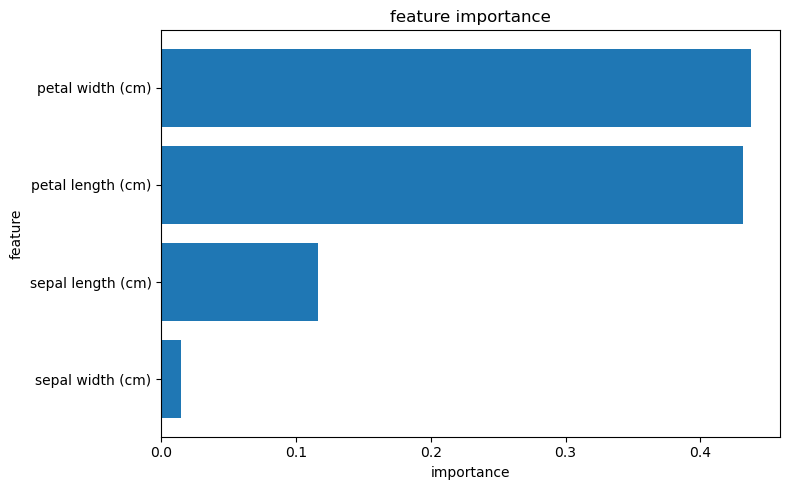

In [17]:
plt.figure(figsize = (8,5))

plt.barh(
    importance['feature'],
    importance['importance']
) 

plt.xlabel('importance')
plt.ylabel("feature")
plt.title("feature importance")

#plt.gca().invert_yaxis()# x축과 y축 순서를 뒤집음
plt.tight_layout()
plt.show()

새로운 데이터를가져다가 학습과 훈련된 모델을 바탕으로 품종 예측

In [18]:


# y_pred = model.predict(X_test)
input_data = []

input_data.append(float(input('꽃받침 길이 입력')))
input_data.append(float(input('꽃받침 넓이 입력')))
input_data.append(float(input('꽃잎 길이 입력')))
input_data.append(float(input('꽃잎 넓이 입력')))


꽃받침 길이 입력 5.0
꽃받침 넓이 입력 4.0
꽃잎 길이 입력 2.0
꽃잎 넓이 입력 0.2


In [19]:
input_data

[5.0, 4.0, 2.0, 0.2]

In [20]:
input_df = pd.DataFrame([input_data], columns = ['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)'])

In [21]:
input_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.0,4.0,2.0,0.2


In [22]:
pred = model.predict(input_df)

In [23]:
print('예측 결과 : ',pred)

예측 결과 :  ['setosa']


In [24]:
def predict_species():
    input_data = []

    input_data.append(float(input('꽃받침 길이 입력')))
    input_data.append(float(input('꽃받침 넓이 입력')))
    input_data.append(float(input('꽃잎 길이 입력')))
    input_data.append(float(input('꽃잎 넓이 입력')))
    
    input_df = pd.DataFrame([input_data], columns = ['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)'])
    
    pred = model.predict(input_df)
    
    print('예측 결과 : ',pred)

In [25]:
predict_species()

꽃받침 길이 입력 4.0
꽃받침 넓이 입력 3.0
꽃잎 길이 입력 2.0
꽃잎 넓이 입력 1.0


예측 결과 :  ['setosa']
